- Load the dataset and explore the message content and labels.
-Identify how many messages belong to each category.
- Build a probabilistic classification model that can learn patterns from word occurrences.
- Train the model using historical message data.
- Predict whether unseen messages are:
    - Suspicious
    - Not suspicious
- Test the system using custom user-entered messages.
- Evaluate the model using appropriate classification metrics.
- Analyze the following:
    - How many suspicious messages were correctly identified?
    - How many genuine messages were incorrectly flagged?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Read the CSV file
df = pd.read_csv(r'spams.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
print('no of messages that are ham = ',len(df.value_counts()[0]))
print('no of messages that are ham = ',len(df.value_counts()[1]))

no of messages that are ham =  4516
no of messages that are ham =  653


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

X = df['text']
y = df['label']

vectorizer = CountVectorizer(stop_words='english')
X_vec = vectorizer.fit_transform(X)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:
y_pred = model.predict(X_test)

In [20]:
text_sam = input("Enter the message: ")
text_vec = vectorizer.transform([text_sam])
prediction = model.predict(text_vec)
if prediction[0]==0:
    print('ham msg')
else:
    print('spam msg')


ham msg


In [14]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9802690582959641

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



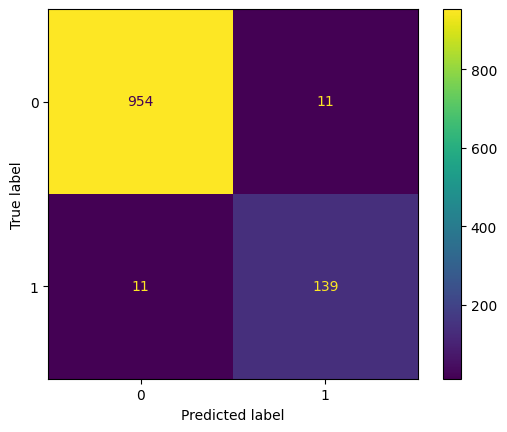

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)